<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

### Notebook 3
### Introduction to Multiple Regression

In [3]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

  Cloning https://github.com/dnepple/tprstats-python (to revision colab) to /tmp/pip-req-build-j53_ud4q
  Running command git clone --filter=blob:none --quiet https://github.com/dnepple/tprstats-python /tmp/pip-req-build-j53_ud4q
  Running command git checkout -b colab --track origin/colab
  Switched to a new branch 'colab'
  Branch 'colab' set up to track remote branch 'colab' from 'origin'.
  Resolved https://github.com/dnepple/tprstats-python to commit d5b7ac1c19bfee3ed707aefeeb1cbc04ba8934ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.0 MB/s eta 0:00:00
  Created wheel for tprstats: filename=tprstats-0.1.0-py3-none-any.whl size=11433 sha256=e38399a69178cc4de2bccb588e13689ac49ea560fcd08e774bb7d0755111c884
  Stored in directory: /tmp/pip-ephem-wheel-cache-2uqr5r4p/wheels/5d/0e/3a/ef7ae3e58a9bf61b5c91546d764aaf5ac5df485b9ce38295fe
Succ

In [2]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder
%cd '/content/drive/MyDrive/SDM'

Mounted at /content/drive
/content/drive/MyDrive/SDM


In [4]:
%precision %.4f
#import tprstats
import pandas
import matplotlib.pyplot as plt
# from scipy.stats import t
# from statsmodels import stats

We will study data for 211 diamonds. This data set has the Price for which each diamond sold as well as the Carat weight of each diamond and the Clarity of each. The data set also has a variable named Color. As you will see below, all diamonds in this data set have Color=11. These diamonds were sold by 9 different sales people. We will study this variable in a later class.

In [5]:
# import dataset Diamonds_211
Diamonds_211 = pandas.read_excel("data/Diamonds_211.xlsx")

In [6]:
# view summary statistics
Diamonds_211.describe()

,Price,Carat,Clarity,Color,Cut,Salesperson
count,211.000000,211.000000,211.000000,211.0,211.0,211.000000
mean,8769.364929,1.239573,4.270142,11.0,2.0,5.208531
std,5744.400127,0.511450,1.206336,0.0,0.0,2.469649
min,2056.000000,0.510000,2.000000,11.0,2.0,1.000000
25%,4037.500000,0.800000,3.000000,11.0,2.0,3.000000
50%,6914.000000,1.110000,4.000000,11.0,2.0,5.000000
75%,11750.500000,1.585000,5.000000,11.0,2.0,7.000000
max,28546.000000,2.470000,8.000000,11.0,2.0,9.000000


In [7]:
# Estimate Diamond regression
DiamReg = tprstats.model("cs", "Price~Carat+Clarity", Diamonds_211)

In [8]:
# view the regression summary
DiamReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
No. Observations:                 211   F-statistic:                     773.8
Covariance Type:                  HC1   Prob (F-statistic):           4.54e-97
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -1.16e+04    759.549    -15.278      0.000   -1.31e+04   -1.01e+04
Carat       1.193e+04    314.094     37.973      0.000    1.13e+04    1.25e+04
Clarity     1308.8177    124.664     10.499      0.000    1063.051    1554.584
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [9]:
# Calculate fitted values and name them yhat
yhat = DiamReg.predict()
# Calculate residuals and name them resid
resid = DiamReg.resid

In [10]:
# Create a data frame containing actual prices, fitted prices, and residuals
ActFitResid= pandas.DataFrame({
    "Price": Diamonds_211['Price'].copy(),
    "yhat": yhat,
    "resid": resid
    })
# View some rows of the data frame
ActFitResid

,Price,yhat,resid
0,11102,11289.737033,-187.737033
1,10228,11289.737033,-1061.737033
2,11389,13198.080296,-1809.080296
3,13504,15225.695012,-1721.695012
4,13657,15822.052282,-2165.052282
...,...,...,...
206,2843,5545.697267,-2702.697267
207,4720,7334.769076,-2614.769076
208,11340,11389.998508,-49.998508
209,9621,11628.541416,-2007.541416


In [11]:
# If you wish to save your results, you can place the results to an Excel file
# The file can then be put the in your Colab drive with your notebooks and data.
ActFitResid.to_excel('/content/drive/MyDrive/ActFitResid.xlsx', index=False)

<Axes: ylabel='Frequency'>

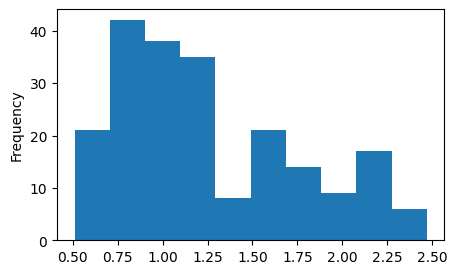

In [12]:
# Let's view a histogram for Carat
# This command controls the size of your figure. For practice, try a few different values.
plt.figure(figsize=(5, 3))
# This command plots the histogram
Diamonds_211['Carat'].plot.hist()

<Axes: ylabel='Frequency'>

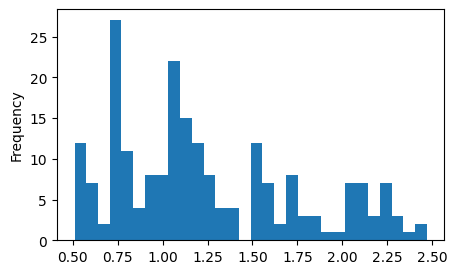

In [13]:
# If we wish, using bins, we can use a more fine-grained horizontal axis
plt.figure(figsize=(5, 3))
Diamonds_211['Carat'].plot.hist(bins=30)


We now show how to enter and format a plot. The first line of code specifies the size of the figure. It specifies a rectangular figure with width as the first entry and height as the second. The second specifies that the variable on the horizontal axis will be Carat and the variable on the vertical axis will be resid. The dots on the graph are to be black in color. The size of the dots is made relatively small by setting s=7. You might want to try varying the entries in the first two lines to get an idea of how they change the plot.
The third fourth and fifth lines of code provide the title and the labels of the x and y axes. The last command specifies a red horizontal line at zero. From the nonlinear pattern in this plot tells us that our estimated model does not capture the effect of clarity very well.

##  Multiple Regression: Hypothesis Testing

In [14]:
# p-values and confidence intervals for coefficients are useful for hypothesis testing.
DiamReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
No. Observations:                 211   F-statistic:                     773.8
Covariance Type:                  HC1   Prob (F-statistic):           4.54e-97
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -1.16e+04    759.549    -15.278      0.000   -1.31e+04   -1.01e+04
Carat       1.193e+04    314.094     37.973      0.000    1.13e+04    1.25e+04
Clarity     1308.8177    124.664     10.499      0.000    1063.051    1554.584
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

The wald test is quite versatile. It will become one of your favorits for hypothesis testing. Below are two applications of the Wald test. Let's evaluate the results using significance level $\alpha$ =.05

In [15]:
# Test the null hypothesis population coefficient of Carat = 13,000
DiamReg.wald_test("Carat = 13000")

p-value:  0.0008


With significance level .05, we reject because the above p-value is less than .05.

In [16]:
# Test the null hypothesis that the population coefficient of Carat = 12,000
# and the population coefficient of Clarity =1250.
DiamReg.wald_test(('Carat = 12000, Clarity=1250'))

p-value:  0.7698


With significance level .05, we do not reject because the above p-value is greater than .05.

## Multiple Regression: Prediction

Below we put the Carat and Clarity values for the three new diamonds into a data frame and name the data frame Xnew. We then obtain the predicted prices using the name of our regression, DiamReg, in the command.

In [17]:
# Put the Carat and Clarity data into a data frame named Xnew.
Xnew = pandas.DataFrame({
    'Carat': [0.8, 1.3, 2.5],
    'Clarity': [7,6,2]
})

In [18]:
# Predict prices for the three diamonds
DiamReg.predict(Xnew)

,0
0,7099.394498
1,11754.149530
2,20831.453346


Often we want a prediction interval along with the prediction. This is accomplished by the command below. We again use the name of our regression, DiamReg, in the command. As you will see, the predicted values are exactly the same as we obtained above. We also obtain the 95% prediction interval for each of the diamonds.

In [19]:
# predict intervals
DiamReg.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,7099.394498,4490.648361,9708.140634
1,11754.149530,9164.138653,14344.160407
2,20831.453346,18177.742958,23485.163733


The default confidence interval is for a 95% interval.
You can choose a different confidence interval by changing alpha.


In [20]:
# Here is the command to calculate a 90% prediction interval.
DiamReg.prediction_intervals(Xnew, alpha=0.1)

,Predicted,Lower,Upper
0,7099.394498,4913.066569,9285.722426
1,11754.149530,9583.523176,13924.775884
2,20831.453346,18607.441951,23055.464741


If you have multiple cases for which you wish to do prediction, you may wish to put the predictor variables in an Excel file.
For Practice: Put Carat and Clarity values below in an Excel file named Diamond_Prediction_Data.xlsx. Then upload the Excel file into your Colab collection of data sets.

>



| Carat | Clarity |
| --- | --- |
| 0.8 | 7 |
| 1.3 | 6 |
| 2.5 | 2 |

In [21]:
# Import the file
Diamond_Prediction_Data = pandas.read_excel("data/Diamond_Prediction_Data.xlsx")
# Execute the following command.
DiamReg.prediction_intervals(Diamond_Prediction_Data)

,Predicted,Lower,Upper
0,7099.394498,4490.648361,9708.140634
1,11754.149530,9164.138653,14344.160407
2,20831.453346,18177.742958,23485.163733


## Multiple Regression: Bias from Leaving out A Variable That Should Be Included

In [22]:
# Estimate regression leaving out Carat
RegNoCarat = tprstats.model("cs", "Price~Clarity", Diamonds_211)

In [23]:
# View the regression result
RegNoCarat.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.030
No. Observations:                 211   F-statistic:                     9.984
Covariance Type:                  HC1   Prob (F-statistic):            0.00181
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.253e+04   1123.542     11.155      0.000    1.03e+04    1.47e+04
Clarity     -881.2864    278.917     -3.160      0.002   -1431.138    -331.435
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In the above regression we obtain a negative coefficient for Clarity. Think about the intuition. Larger diamonds in our data sell for more than smaller diamonds. Larger diamonds have lower clarity than smaller diamonds. Hence, if do not control for Carat in the regression, the Clarity variable tries to do double duty. It controls for the effect of clarity and it captures the negative association between clarity and carat. The latter dominates the former, giving the negative coefficient of clarity.
This is where your expertise comes into play. As a manager, you will develop expertise in the domain in which you are working. You will have a good idea of what explanatory variables should be included when you build a regression model. You can also talk with your colleagues to tap their expertise.

In [24]:
# Calculate Correlation of Carat and Clarity
Diamonds_211['Carat'].corr(Diamonds_211['Clarity'])

np.float64(-0.43310511670623253)

For reasons of confidentiality, I cannot share with you the data used for the regression studying GPA of Tepper graduates.

The following are the commands I used to estimate the regressions that are shown in the slides accompanying this notebook.

```python
# MBA regression with GMATVERBAL included
MBAReg1 = tprstats.model("cs", "TotalGPA ~ GMATQuant + GMATVerbal + GMATWriting \
                         + UGPA + Workyears +I(Workyears**2)", MBA_data)

# MBA regression with GMATVERBAL excluded
MBAReg2 = tprstats.model("cs", "TotalGPA ~ GMATQuant + GMATWriting + UGPA \
                         + Workyears + I(Workyears**2)", MBA_data)
```

In [25]:
# Calculate fitted values and name them yhat
yhat = DiamReg.predict()
# Calculate residuals and name them resid
resid = DiamReg.resid

In [26]:
# Create a data frame containing actual prices, fitted prices, and residuals
ActFitResid= pandas.DataFrame({
    "Price": Diamonds_211['Price'].copy(),
    "yhat": yhat,
    "resid": resid
    })
# View some rows of the data frame
ActFitResid

,Price,yhat,resid
0,11102,11289.737033,-187.737033
1,10228,11289.737033,-1061.737033
2,11389,13198.080296,-1809.080296
3,13504,15225.695012,-1721.695012
4,13657,15822.052282,-2165.052282
...,...,...,...
206,2843,5545.697267,-2702.697267
207,4720,7334.769076,-2614.769076
208,11340,11389.998508,-49.998508
209,9621,11628.541416,-2007.541416


In [27]:
# If you wish to save your results, you can place the results in an Excel file
# in your Colab drive with your notebooks and data.
ActFitResid.to_excel('/content/drive/MyDrive/ActFitResid.xlsx', index=False)

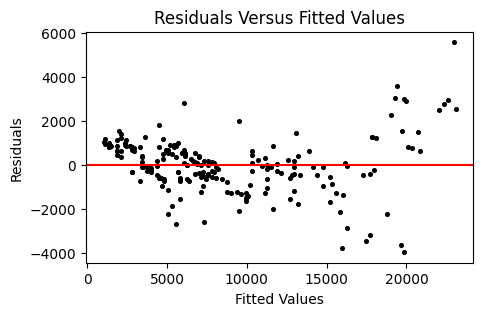

In [28]:
# Plot fitted diamond prices against actual diamond prices
# We see that the model under-predicts for low and high prices and over-predicts intermediate prices.
# This graph and the previous graph are useful diagnostics in assessing suitability of the estimated model.
# In the near future, we will see how to develop a model that better fits these data.
plt.figure(figsize=(5,3))
plt.scatter(yhat, resid,s=7,color='black')
plt.title("Residuals Versus Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

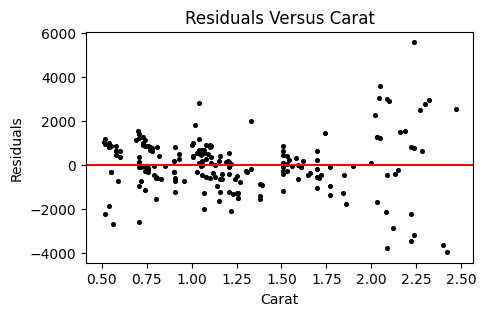

In [29]:
# Plot residuals versus Carat
plt.figure(figsize=(5, 3))
plt.scatter(Diamonds_211['Carat'], resid,s=7,color='black')
plt.title("Residuals Versus Carat")
plt.xlabel("Carat")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

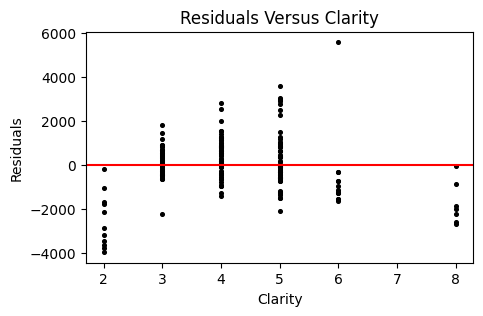

In [30]:
# Plot residuals versus Clarity
plt.figure(figsize=(5, 3))
plt.scatter(Diamonds_211['Clarity'], resid,s=7,color='black')
plt.title("Residuals Versus Clarity")
plt.xlabel("Clarity")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

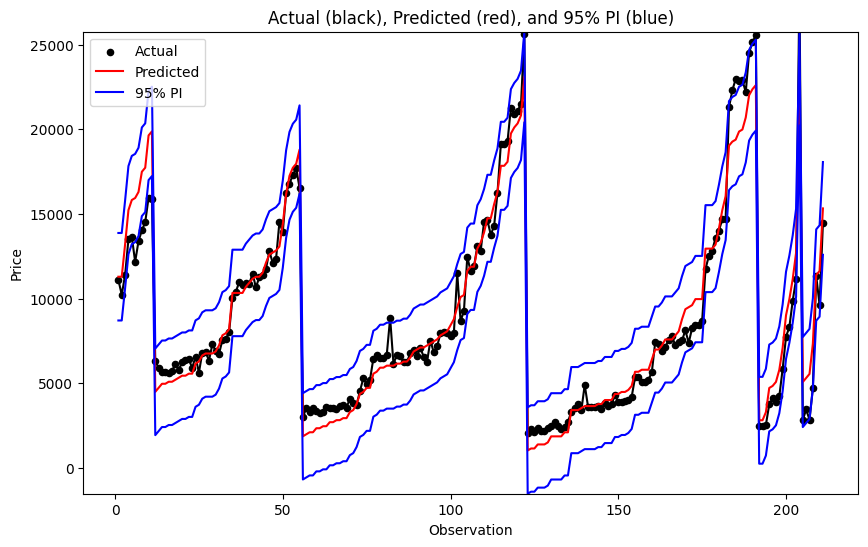

In [31]:
# Plot actual prices (black dots), fitted values (red),
# and 95% prediction intervals (blue)
# Regression name, DiamReg

DiamReg.plot_actual_fitted()